# Food Waste Estimation -- Training Pipeline

5-fold GroupKFold cross-validation training of the single-task dual-stream EfficientNet-B0 model.
Runs on local (CPU/GPU) and Google Colab Pro (T4 GPU).

**Run cells top to bottom. Do not skip the setup cell.**

## 0. Environment Setup

In [1]:
import os, sys

try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    PROJECT_ROOT = '/content/drive/MyDrive/ml-food-waste-estimation'  # adjust if needed
    os.chdir(PROJECT_ROOT)
else:
    if os.path.basename(os.getcwd()) == 'notebooks':
        os.chdir('..')
    PROJECT_ROOT = os.getcwd()

sys.path.insert(0, 'src')
print(f'{"Colab" if IN_COLAB else "Local"} | cwd: {os.getcwd()}')

Local | cwd: e:\work\64.ml-food-estimation\repo


## 1. Install Dependencies

In [2]:
if IN_COLAB:
    import subprocess
    subprocess.run(['pip', 'install', '-r', 'requirements.txt'], check=True)
    print('Dependencies installed.')
else:
    print('Local: run "uv sync" in terminal if not done yet.')

Local: run "uv sync" in terminal if not done yet.


## 2. Imports and Config

In [3]:
%matplotlib inline
import glob
import json
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, WeightedRandomSampler
from sklearn.model_selection import GroupKFold

from utils import set_seed, compute_mae, compute_rmse
from dataset import FoodWasteDataset, load_metadata, get_transforms, compute_class_weights
from model import DualStreamEfficientNet

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Training config -- edit here
CONFIG = {
    'folds':         10,
    'epochs':        100,
    'lr':            1e-4,
    'batch_size':    16,
    'patience':      20,
    'frozen_epochs': 10,
    'seed':          42,
    'num_workers':   2,
    'pin_memory':    DEVICE.type == 'cuda',
}

# Paths
DATA_DIR       = 'data'
BEFORE_DIR     = os.path.join(DATA_DIR, 'segmented', 'data_before')
AFTER_DIR      = os.path.join(DATA_DIR, 'segmented', 'data_after')
CHECKPOINT_DIR = 'checkpoints'
RESULTS_DIR    = 'results'
os.makedirs(RESULTS_DIR, exist_ok=True)

print(f'Device: {DEVICE}')
print(f'Config: {CONFIG}')

Device: cpu
Config: {'folds': 10, 'epochs': 100, 'lr': 0.0001, 'batch_size': 16, 'patience': 20, 'frozen_epochs': 10, 'seed': 42, 'num_workers': 2, 'pin_memory': False}


## 3. Load and Filter Metadata

In [4]:
set_seed(CONFIG['seed'])

df, norm_params = load_metadata(
    os.path.join(DATA_DIR, 'data_original.xlsx'),
    before_dir=BEFORE_DIR,
    after_dir=AFTER_DIR,
    save_dir=RESULTS_DIR
)

print(f'Usable samples : {len(df)}')
print(f'Food categories: {df["group"].nunique()}')
print(f'Target         : {norm_params["target"]}')
print(f'Ratio range    : {df["consumption_ratio"].min():.3f} -- {df["consumption_ratio"].max():.3f}')
df.head()

2026-06-28 22:53:57.436 | WARNING  | dataset:load_metadata:32 - Found 19 samples where after-weight > before-weight. Capping to before-weight.
2026-06-28 22:53:57.441 | INFO     | dataset:load_metadata:53 - Skipped 154 samples with missing segmented images (524 usable).


Usable samples : 524
Food categories: 34
Target         : consumption_ratio
Ratio range    : 0.000 -- 1.000


,ID,Name of the food,Image Before Eaten,Weight Before Eaten (g),Image After Eaten,Weight After Eaten (g),Visual Estimation by Observer (1-7),Weight Leftover (g),consumption_ratio,group
0,1,Bubur,000_000_DSC_0016_bef.JPG,343,000_000_DSC_0032_aft.JPG,330,1,13,0.962099,Bubur
1,2,Nasi,001_001_DSC_0059_bef.JPG,130,001_001_DSC_0108_aft.JPG,122,3,8,0.938462,Nasi
2,3,Nasi,001_002_DSC_0066_bef.JPG,135,001_002_DSC_0095_aft.JPG,127,1,8,0.940741,Nasi
3,4,Nasi,001_003_DSC_0067_bef.JPG,146,001_003_DSC_0097_aft.JPG,1,7,145,0.006849,Nasi
4,5,Nasi,001_008_DSC_0055_bef.JPG,139,001_008_DSC_0101_aft.JPG,25,6,114,0.179856,Nasi


## 4. Training

In [5]:
train_transform = get_transforms('train')
val_transform   = get_transforms('val')

# Outer 10-fold: each fold yields a held-out test set (1/10) and trainval (9/10)
outer_gkf = GroupKFold(n_splits=CONFIG['folds'])
# Inner 5-fold on trainval: first split gives val (~20% of trainval ~ 2/10 total)
inner_gkf = GroupKFold(n_splits=5)

groups = df['group'].values

criterion = nn.HuberLoss(delta=0.1)

fold_indices       = {}
fold_val_maes      = []
fold_test_maes     = []
fold_test_gram_maes  = []
fold_test_gram_rmses = []
fold_logs          = {}

for fold_n, (trainval_idx, test_idx) in enumerate(
    outer_gkf.split(np.arange(len(df)), groups=groups), start=1
):
    print(f'\n{"="*60}')
    print(f'Fold {fold_n}/{CONFIG["folds"]}')
    print(f'{"="*60}')

    set_seed(CONFIG['seed'] + fold_n)

    trainval_df = df.iloc[trainval_idx]
    test_df     = df.iloc[test_idx]
    tv_groups   = trainval_df['group'].values

    # Take only the first inner split to define val vs train
    inner_train_local, val_local = next(
        inner_gkf.split(np.arange(len(trainval_df)), groups=tv_groups)
    )
    train_df = trainval_df.iloc[inner_train_local]
    val_df   = trainval_df.iloc[val_local]

    fold_indices[f'fold_{fold_n}'] = {
        'train': train_df.index.tolist(),
        'val':   val_df.index.tolist(),
        'test':  test_df.index.tolist(),
    }
    print(f'  train: {len(train_df)}, val: {len(val_df)}, test: {len(test_df)}')

    train_ds = FoodWasteDataset(train_df, BEFORE_DIR, AFTER_DIR, train_transform)
    val_ds   = FoodWasteDataset(val_df,   BEFORE_DIR, AFTER_DIR, val_transform)
    test_ds  = FoodWasteDataset(test_df,  BEFORE_DIR, AFTER_DIR, val_transform)

    # Inverse-frequency sample weighting for bimodal ratio distribution
    sample_weights = compute_class_weights(train_df)
    sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)

    train_loader = DataLoader(train_ds, batch_size=CONFIG['batch_size'], sampler=sampler,
                              num_workers=CONFIG['num_workers'], pin_memory=CONFIG['pin_memory'])
    val_loader   = DataLoader(val_ds,   batch_size=CONFIG['batch_size'], shuffle=False,
                              num_workers=CONFIG['num_workers'], pin_memory=CONFIG['pin_memory'])
    test_loader  = DataLoader(test_ds,  batch_size=CONFIG['batch_size'], shuffle=False,
                              num_workers=CONFIG['num_workers'], pin_memory=CONFIG['pin_memory'])

    model = DualStreamEfficientNet(pretrained=True).to(DEVICE)
    model.freeze_backbone()

    head_params     = list(model.fusion.parameters()) + list(model.regression_head.parameters())
    backbone_params = list(model.backbone.parameters())
    optimizer = torch.optim.Adam(
        [{'params': head_params}, {'params': backbone_params}],
        lr=CONFIG['lr'],
    )
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=5, min_lr=1e-6
    )

    best_val_mae      = float('inf')
    epochs_no_improve = 0
    log_rows          = []

    for epoch in range(1, CONFIG['epochs'] + 1):
        if epoch == CONFIG['frozen_epochs'] + 1:
            model.unfreeze_backbone()
            optimizer.param_groups[1]['lr'] = CONFIG['lr']
            # Reset scheduler so LR-reduction patience counts from the unfreeze point.
            scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
                optimizer, mode='min', factor=0.5, patience=5, min_lr=1e-6
            )

        model.train()
        train_losses = []
        for batch in train_loader:
            before       = batch['before'].to(DEVICE)
            after        = batch['after'].to(DEVICE)
            area_ratio   = batch['area_ratio'].to(DEVICE)
            target       = batch['consumption_ratio'].to(DEVICE)

            optimizer.zero_grad()
            pred = model(before, after, area_ratio)
            loss = criterion(pred, target)
            loss.backward()
            optimizer.step()
            train_losses.append(loss.item())

        model.eval()
        val_preds, val_targets, val_losses = [], [], []
        with torch.no_grad():
            for batch in val_loader:
                before     = batch['before'].to(DEVICE)
                after      = batch['after'].to(DEVICE)
                area_ratio = batch['area_ratio'].to(DEVICE)
                target     = batch['consumption_ratio'].to(DEVICE)

                pred = model(before, after, area_ratio)
                val_losses.append(criterion(pred, target).item())
                val_preds.append(pred.cpu())
                val_targets.append(target.cpu())

        val_preds   = torch.cat(val_preds)
        val_targets = torch.cat(val_targets)
        val_mae     = compute_mae(val_preds, val_targets)
        val_rmse    = compute_rmse(val_preds, val_targets)
        scheduler.step(val_mae)

        print(f'  Epoch {epoch:3d} | '
              f'Train Loss: {np.mean(train_losses):.4f} | '
              f'Val Loss: {np.mean(val_losses):.4f} | '
              f'Val MAE: {val_mae:.4f} | '
              f'LR: {optimizer.param_groups[0]["lr"]:.2e}')

        log_rows.append({
            'epoch':       epoch,
            'train_loss':  float(np.mean(train_losses)),
            'val_loss':    float(np.mean(val_losses)),
            'val_mae':     val_mae,
            'val_rmse':    val_rmse,
            'lr':          optimizer.param_groups[0]['lr'],
        })

        if val_mae < best_val_mae:
            best_val_mae      = val_mae
            epochs_no_improve = 0
            os.makedirs(CHECKPOINT_DIR, exist_ok=True)
            torch.save({
                'fold':                 fold_n,
                'epoch':                epoch,
                'model_state_dict':     model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'val_mae':              best_val_mae,
                'normalization_params': norm_params,
            }, os.path.join(CHECKPOINT_DIR, f'fold_{fold_n}_best.pth'))
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= CONFIG['patience']:
                print(f'  Early stopping at epoch {epoch}')
                break

    # Evaluate on held-out test set using the best checkpoint
    best_ckpt = torch.load(
        os.path.join(CHECKPOINT_DIR, f'fold_{fold_n}_best.pth'),
        map_location=DEVICE,
        weights_only=False,
    )
    model.load_state_dict(best_ckpt['model_state_dict'])
    model.eval()
    test_preds, test_targets_list, test_wb = [], [], []
    with torch.no_grad():
        for batch in test_loader:
            before     = batch['before'].to(DEVICE)
            after      = batch['after'].to(DEVICE)
            area_ratio = batch['area_ratio'].to(DEVICE)
            target     = batch['consumption_ratio'].to(DEVICE)
            pred = model(before, after, area_ratio)
            test_preds.append(pred.cpu())
            test_targets_list.append(target.cpu())
            test_wb.append(batch['weight_before'].float())

    preds_t   = torch.cat(test_preds)
    targets_t = torch.cat(test_targets_list)
    wb_t      = torch.cat(test_wb)
    test_mae       = compute_mae(preds_t, targets_t)
    test_gram_mae  = compute_mae(preds_t * wb_t, targets_t * wb_t)
    test_gram_rmse = compute_rmse(preds_t * wb_t, targets_t * wb_t)

    fold_val_maes.append(best_val_mae)
    fold_test_maes.append(test_mae)
    fold_test_gram_maes.append(test_gram_mae)
    fold_test_gram_rmses.append(test_gram_rmse)
    fold_logs[fold_n] = pd.DataFrame(log_rows)
    fold_logs[fold_n].to_csv(os.path.join(RESULTS_DIR, f'fold_{fold_n}_log.csv'), index=False)
    print(f'Fold {fold_n} -- val MAE: {best_val_mae:.4f} | test MAE: {test_mae:.4f}')

    # Partial save so results survive a mid-training crash
    with open(os.path.join(RESULTS_DIR, 'summary.json'), 'w') as f:
        json.dump({
            'fold_val_maes': fold_val_maes,
            'fold_test_maes': fold_test_maes,
            'fold_test_gram_maes': fold_test_gram_maes,
            'fold_test_gram_rmses': fold_test_gram_rmses,
        }, f, indent=2)

with open(os.path.join(RESULTS_DIR, 'fold_indices.json'), 'w') as f:
    json.dump(fold_indices, f, indent=2)

pd.concat(fold_logs.values(), ignore_index=True).assign(
    fold=sum([[k]*len(v) for k, v in fold_logs.items()], [])
).to_csv(os.path.join(RESULTS_DIR, 'all_folds_log.csv'), index=False)

print(f'\nAll folds complete.')


Fold 1/10
  train: 356, val: 90, test: 78


  Epoch   1 | Train Loss: 0.0158 | Val Loss: 0.0142 | Val MAE: 0.1913 | LR: 1.00e-04
  Epoch   2 | Train Loss: 0.0123 | Val Loss: 0.0129 | Val MAE: 0.1602 | LR: 1.00e-04
  Epoch   3 | Train Loss: 0.0105 | Val Loss: 0.0120 | Val MAE: 0.1509 | LR: 1.00e-04
  Epoch   4 | Train Loss: 0.0118 | Val Loss: 0.0113 | Val MAE: 0.1447 | LR: 1.00e-04
  Epoch   5 | Train Loss: 0.0097 | Val Loss: 0.0134 | Val MAE: 0.1635 | LR: 1.00e-04
  Epoch   6 | Train Loss: 0.0099 | Val Loss: 0.0120 | Val MAE: 0.1516 | LR: 1.00e-04
  Epoch   7 | Train Loss: 0.0101 | Val Loss: 0.0114 | Val MAE: 0.1501 | LR: 1.00e-04
  Epoch   8 | Train Loss: 0.0099 | Val Loss: 0.0158 | Val MAE: 0.1897 | LR: 1.00e-04
  Epoch   9 | Train Loss: 0.0112 | Val Loss: 0.0117 | Val MAE: 0.1513 | LR: 1.00e-04
  Epoch  10 | Train Loss: 0.0090 | Val Loss: 0.0117 | Val MAE: 0.1486 | LR: 5.00e-05
  Epoch  11 | Train Loss: 0.0076 | Val Loss: 0.0112 | Val MAE: 0.1421 | LR: 5.00e-05
  Epoch  12 | Train Loss: 0.0066 | Val Loss: 0.0118 | Val MAE: 0.

## 5. Results Summary

Mean Test MAE : 0.1076 +/- 0.0308
Mean Val  MAE : 0.1060
Baseline      : 0.0926  |  Beats baseline: False


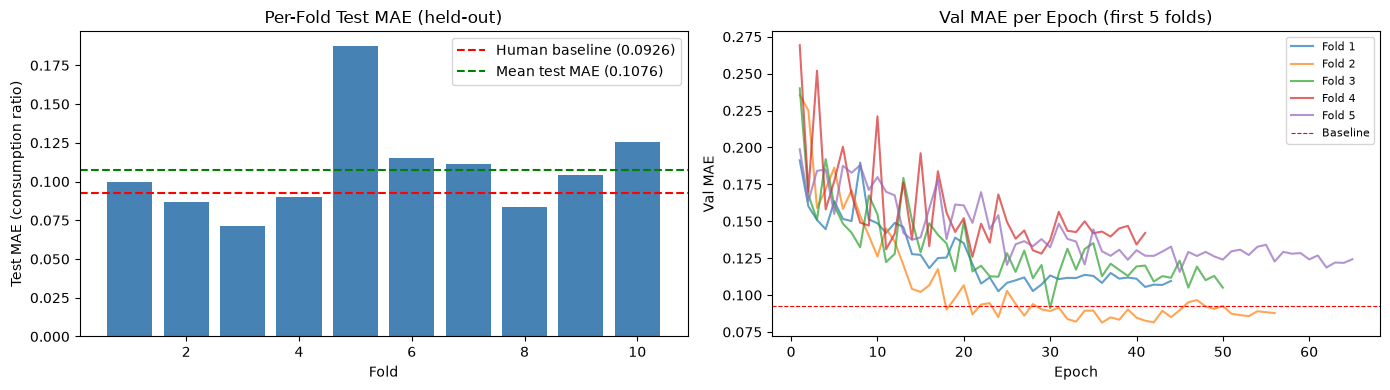

In [6]:
# Recover fold_maes and fold_logs from disk if the kernel was restarted after training.
try:
    fold_test_maes
    fold_val_maes
except NameError:
    with open(os.path.join(RESULTS_DIR, 'summary.json')) as _f:
        _s = json.load(_f)
    fold_val_maes        = _s['fold_val_maes']
    fold_test_maes       = _s['fold_test_maes']
    fold_test_gram_maes  = _s.get('fold_test_gram_maes', [])
    fold_test_gram_rmses = _s.get('fold_test_gram_rmses', [])
    print('Loaded fold MAEs from summary.json')

try:
    fold_logs
except NameError:
    fold_logs = {}
    for _csv in sorted(glob.glob(os.path.join(RESULTS_DIR, 'fold_*_log.csv'))):
        _n = int(os.path.basename(_csv).split('_')[1])
        fold_logs[_n] = pd.read_csv(_csv)
    print(f'Loaded {len(fold_logs)} fold logs from disk')

summary = {
    'fold_val_maes':        fold_val_maes,
    'fold_test_maes':       fold_test_maes,
    'fold_test_gram_maes':  fold_test_gram_maes,
    'fold_test_gram_rmses': fold_test_gram_rmses,
    'mean_val_mae':         float(np.mean(fold_val_maes)),
    'mean_test_mae':        float(np.mean(fold_test_maes)),
    'mean_test_gram_mae':   float(np.mean(fold_test_gram_maes)) if fold_test_gram_maes else None,
    'std_test_mae':         float(np.std(fold_test_maes)),
    'human_baseline_mae':   0.0926,
    'beats_baseline':       float(np.mean(fold_test_maes)) < 0.0926,
}
with open(os.path.join(RESULTS_DIR, 'summary.json'), 'w') as f:
    json.dump(summary, f, indent=2)

print(f'Mean Test MAE : {summary["mean_test_mae"]:.4f} +/- {summary["std_test_mae"]:.4f}')
print(f'Mean Val  MAE : {summary["mean_val_mae"]:.4f}')
print(f'Baseline      : 0.0926  |  Beats baseline: {summary["beats_baseline"]}')

# Per-fold test MAE bar chart
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].bar(range(1, len(fold_test_maes) + 1), fold_test_maes, color='steelblue')
axes[0].axhline(0.0926, color='red', linestyle='--', label='Human baseline (0.0926)')
axes[0].axhline(summary['mean_test_mae'], color='green', linestyle='--',
                label=f'Mean test MAE ({summary["mean_test_mae"]:.4f})')
axes[0].set_xlabel('Fold')
axes[0].set_ylabel('Test MAE (consumption ratio)')
axes[0].set_title('Per-Fold Test MAE (held-out)')
axes[0].legend()

# Training curves per fold (first 5 shown to keep the plot readable)
shown_folds = sorted(fold_logs.keys())[:5]
for ax_idx, fold_n in enumerate(shown_folds):
    log = fold_logs[fold_n]
    axes[1].plot(log['epoch'], log['val_mae'], label=f'Fold {fold_n}', alpha=0.7)
axes[1].axhline(0.0926, color='red', linestyle='--', linewidth=0.8, label='Baseline')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Val MAE')
axes[1].set_title('Val MAE per Epoch (first 5 folds)')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'fold_mae.png'), dpi=120)
plt.show()